In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r"C:\Users\vishnu priya\Downloads\TravelInsurancePrediction.csv")
df.head()

,Unnamed: 0,Age,Employment Type,GraduateOrNot,AnnualIncome,FamilyMembers,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,TravelInsurance
0,0,31,Government Sector,Yes,400000,6,1,No,No,0
1,1,31,Private Sector/Self Employed,Yes,1250000,7,0,No,No,0
2,2,34,Private Sector/Self Employed,Yes,500000,4,1,No,No,1
3,3,28,Private Sector/Self Employed,Yes,700000,3,1,No,No,0
4,4,28,Private Sector/Self Employed,Yes,700000,8,1,Yes,No,0


Looking for missing values in the dataset

In [3]:
df.isna().sum()

Unnamed: 0             0
Age                    0
Employment Type        0
GraduateOrNot          0
AnnualIncome           0
FamilyMembers          0
ChronicDiseases        0
FrequentFlyer          0
EverTravelledAbroad    0
TravelInsurance        0
dtype: int64

Droping few columns from the dataset

In [4]:
df.drop(['Unnamed: 0', 'GraduateOrNot'], axis = 1, inplace = True)

In [5]:
df.head()

,Age,Employment Type,AnnualIncome,FamilyMembers,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,TravelInsurance
0,31,Government Sector,400000,6,1,No,No,0
1,31,Private Sector/Self Employed,1250000,7,0,No,No,0
2,34,Private Sector/Self Employed,500000,4,1,No,No,1
3,28,Private Sector/Self Employed,700000,3,1,No,No,0
4,28,Private Sector/Self Employed,700000,8,1,Yes,No,0


In [6]:
df.describe()

,Age,AnnualIncome,FamilyMembers,ChronicDiseases,TravelInsurance
count,1987.000000,1.987000e+03,1987.000000,1987.000000,1987.000000
mean,29.650226,9.327630e+05,4.752894,0.277806,0.357323
std,2.913308,3.768557e+05,1.609650,0.448030,0.479332
min,25.000000,3.000000e+05,2.000000,0.000000,0.000000
25%,28.000000,6.000000e+05,4.000000,0.000000,0.000000
50%,29.000000,9.000000e+05,5.000000,0.000000,0.000000
75%,32.000000,1.250000e+06,6.000000,1.000000,1.000000
max,35.000000,1.800000e+06,9.000000,1.000000,1.000000


Select only numeric columns for correlation

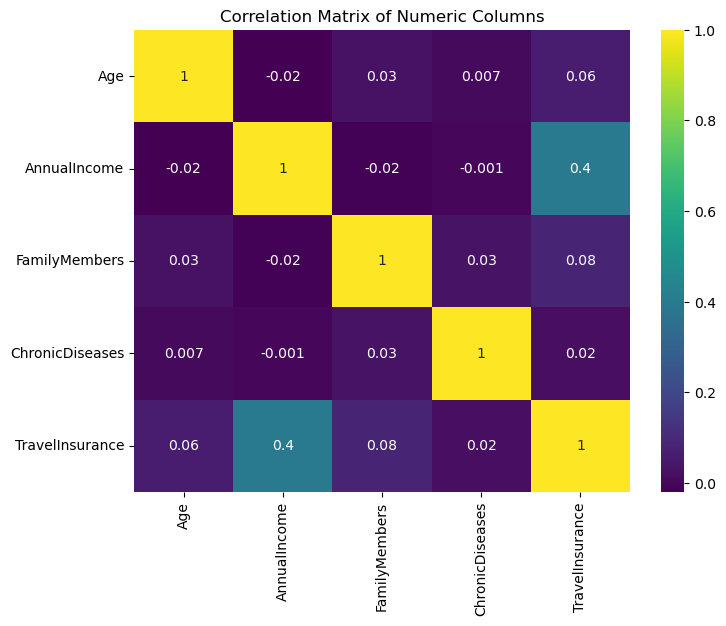

In [7]:
numeric_df = df.select_dtypes(include = 'number')

#Plot the correlation heatmap:
fig, ax = plt.subplots(figsize = (8, 6))
sns.heatmap(numeric_df.corr(), annot = True, fmt = '.1g', cmap = 'viridis', cbar = True)
plt.title('Correlation Matrix of Numeric Columns')
plt.show()

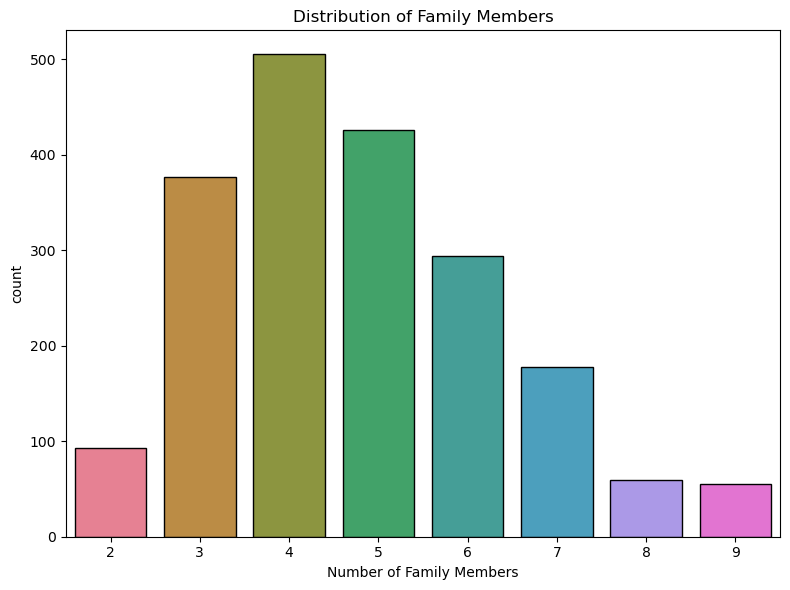

In [8]:
#Create a color palette with as manu colors as there are unique family number of values:
unique_families = df['FamilyMembers'].nunique()
palette = sns.color_palette('husl', unique_families) # 'hpusl' gives vibrant unique colors

#Plot:
fig, ax = plt.subplots(figsize = (8, 6))
sns.countplot(x = 'FamilyMembers', data = df, palette = palette, ax = ax, edgecolor = 'black')

#Beautify:
ax.set_title('Distribution of Family Members')
ax.set_xlabel('Number of Family Members')
ax.set_ylabel('count')
plt.tight_layout()
plt.show()

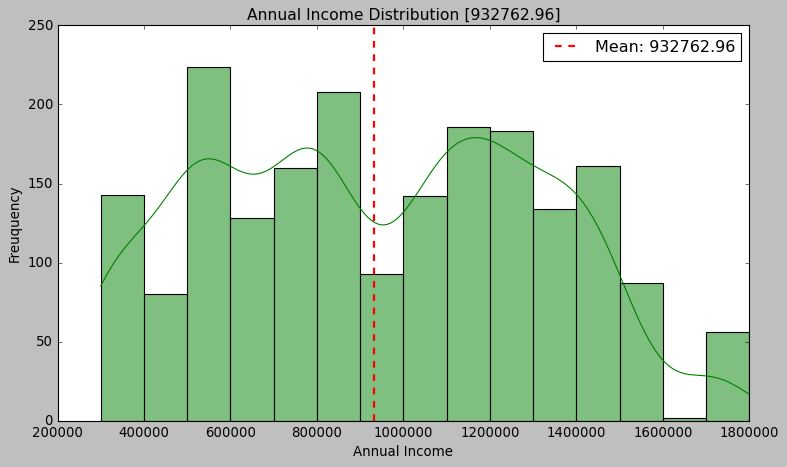

In [9]:
plt.style.use('classic')

#create a plot:
fig, ax = plt.subplots(figsize = (10, 6))
sns.histplot(df['AnnualIncome'], kde = True, color = 'g', ax = ax)

#Beautiify:
mean_income = df['AnnualIncome'].mean()
ax.axvline(mean_income, color = 'red', linestyle = '--', linewidth = 2, label = f"Mean: {mean_income:.2f}")
ax.set_title(f'Annual Income Distribution [{mean_income:.2f}]', fontsize = 14)
ax.set_xlabel('Annual Income', fontsize = 12)
ax.set_ylabel('Freuquency', fontsize = 12)
ax.legend()
plt.tight_layout()        
plt.show()

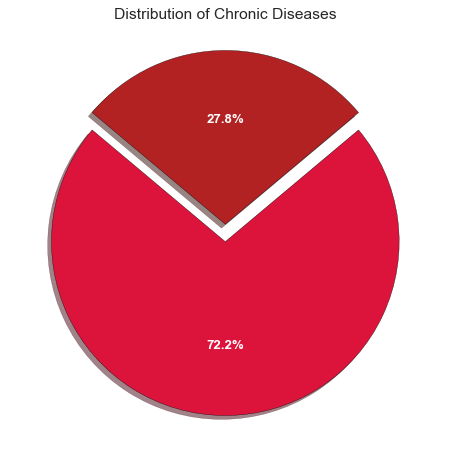

In [10]:
#Use a clean and professional style:
plt.style.use('seaborn-v0_8')

#Get value counts:
disease_counts = df['ChronicDiseases'].value_counts()
labels = ['Non-Chronic', 'Chronic']

#Create the plot:
fig, ax = plt.subplots(figsize = (8, 6))
wedges, texts, autotexts = ax.pie(
    x = disease_counts,
    labels = labels,
    colors = ['crimson', 'firebrick'],
    shadow = True,
    explode = (0, 0.1),
    autopct = '%1.1f%%',
    startangle = 140,
    textprops = dict(color = 'white', fontsize = 12),
)

#Beautify
ax.set_title('Distribution of Chronic Diseases', fontsize = 14)
plt.setp(autotexts, weight = 'bold')
plt.tight_layout()
plt.show()


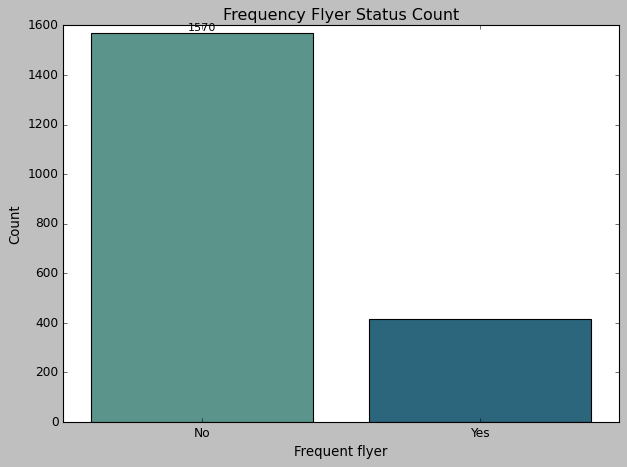

In [11]:
plt.style.use('classic')

#Create the plot:
fig, ax = plt.subplots(figsize = (8, 6))
sns.countplot(x = 'FrequentFlyer', data = df, palette = 'crest', ax = ax)

#Beautify:
ax.set_title('Frequency Flyer Status Count')
ax.set_xlabel('Frequent flyer', fontsize = 12)
ax.set_ylabel('Count', fontsize = 12)
ax.bar_label(ax.containers[0], label_type = 'edge', fontsize = 10)

plt.xticks(fontsize = 11)
plt.yticks(fontsize = 11)
plt.tight_layout()
plt.show()

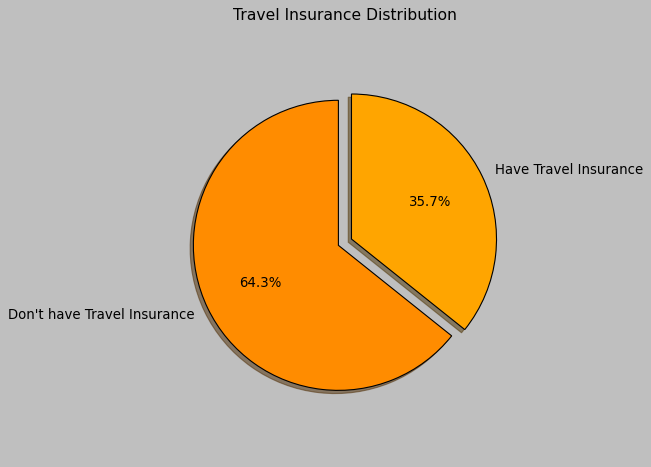

In [12]:
#Pie chart values and labels:
values = df['TravelInsurance'].value_counts()
labels = ["Don't have Travel Insurance", 'Have Travel Insurance']

#Create pie chart:
fig, ax = plt.subplots(figsize = (8, 6))
ax.pie(
    x = values,
    labels = labels,
    colors = ['darkorange', 'orange'],
    autopct = '%1.1f%%',                #show percentage
    explode = (0, 0.1),                 #slight por out for second slice
    shadow = True,
    startangle = 90,                    #start angle for better orientation
    wedgeprops = {"edgecolor":  'black'}  #border for better readability
)

#Title and styling:
ax.set_title('Travel Insurance Distribution', fontsize = 14)
ax.axis('equal')                         #equal aspect ration ensure it's a perfect circle
plt.tight_layout()
plt.show()

In [13]:
#Yes:1, No:0
df['FrequentFlyer'] = df['FrequentFlyer'].map({'Yes':1, 'No':0})
df['EverTravelledAbroad'] = df['EverTravelledAbroad'].map({'Yes':1, 'No':0})

#Government secotr:1, Private sector/self Employed:0
df['Employment Type'] = df['Employment Type'].map({'Government Sector':1, 'Private Sector/Self Employed':0})

In [14]:
#Having a look at the dataset after the numerical transformaction:
df.head()

,Age,Employment Type,AnnualIncome,FamilyMembers,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,TravelInsurance
0,31,1,400000,6,1,0,0,0
1,31,0,1250000,7,0,0,0,0
2,34,0,500000,4,1,0,0,1
3,28,0,700000,3,1,0,0,0
4,28,0,700000,8,1,1,0,0


In [15]:
# X data:
x = df.drop('TravelInsurance', axis = 1)

In [16]:
x.head()

,Age,Employment Type,AnnualIncome,FamilyMembers,ChronicDiseases,FrequentFlyer,EverTravelledAbroad
0,31,1,400000,6,1,0,0
1,31,0,1250000,7,0,0,0
2,34,0,500000,4,1,0,0
3,28,0,700000,3,1,0,0
4,28,0,700000,8,1,1,0


In [17]:
#Y data:
y = df['TravelInsurance']
y.head()

0    0
1    0
2    1
3    0
4    0
Name: TravelInsurance, dtype: int64

In [18]:
#Splitting the data into x train, x test and y train, y test:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.2, random_state = 42)

In [19]:
len(x_train), len(x_test)

(1589, 398)

In [43]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()

In [44]:
rf.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
RandomForestClassifierscore = rf.score(x_test, y_test)
RandomForestClassifierscore


0.8115577889447236

In [23]:
print('Accuracy obtained by RandomForestClassifier model:', RandomForestClassifierscore*100)

Accuracy obtained by RandomForestClassifier model: 81.15577889447236


In [38]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'bootstrap': [True],
    'max_depth': [80, 90, 100, 110],
    'max_features': [2, 3],
    'min_samples_leaf': [3, 4, 5],
    'min_samples_split': [8, 10, 12],
    'criterion': ['gini', 'entropy'],
    'n_estimators': [100, 200, 300, 1000]
}
grid_search_rf = GridSearchCV(estimator = rf,
                              param_grid = param_grid,
                              cv = 3, n_jobs = -1, verbose = 2)

In [39]:
grid_search_rf.fit(x_train, y_train)

Fitting 3 folds for each of 16 candidates, totalling 48 fits


,estimator,RandomForestClassifier()
,param_grid,"{'bootstrap': [True], 'criterion': ['gini'], 'max_depth': [80, 100], 'max_features': [2], ...}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [41]:
grid_search_rf.best_params_

{'bootstrap': True,
 'criterion': 'gini',
 'max_depth': 80,
 'max_features': 2,
 'min_samples_leaf': 3,
 'min_samples_split': 10,
 'n_estimators': 100}

In [42]:
grid_search_rf.best_score_

np.float64(0.8319803592871325)